# 🌦️ Weather Data ETL Pipeline

### Data Analytics Internship — AnalystLab Africa

**Project Executed By:** Egbetola Olanrewaju Emmanuel  
**Internship:** Data Analytics Internship  
**Organization:** AnalystLab Africa  
**Project:** Week 7 — Data Pipelines & Automation

## Project Introduction

This project was developed as part of Week 7 of the AnalystLab Africa Data Analytics Internship. The project focuses on building a basic ETL (Extract, Transform, Load) pipeline using real-time weather data obtained from the OpenWeather API.

The pipeline extracts weather information for selected cities, transforms and cleans the raw data using Python and Pandas, and loads the processed dataset into structured files for analysis.

The project also includes basic exploratory analysis and visualizations to identify differences in temperature, humidity, wind speed, and weather conditions across the selected cities.

## Project Objective

The objective of this project is to demonstrate how real-world data can be collected from an external API, cleaned and transformed into an analysis-ready format, stored efficiently, and used to generate meaningful insights.

## Tools & Technologies

- Python
- Pandas
- Requests
- Matplotlib
- Jupyter Notebook
- OpenWeather API
- Microsoft Excel

## Task 1: Extract Data


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

print("All required libraries imported successfully!")

All required libraries imported successfully!


### 1.A- Connect to the API using your API key

In [2]:
import os

if os.getenv("OPENWEATHER_API_KEY"):
    print("OpenWeather API key detected successfully!")
else:
    print("API key not detected.")

OpenWeather API key detected successfully!


In [3]:
import requests
import os

API_KEY = os.getenv("OPENWEATHER_API_KEY")

city = "Leiria"
url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)
print(response.json())

Status Code: 200
{'coord': {'lon': -8.8071, 'lat': 39.7436}, 'weather': [{'id': 801, 'main': 'Clouds', 'description': 'few clouds', 'icon': '02n'}], 'base': 'stations', 'main': {'temp': 20, 'feels_like': 20.51, 'temp_min': 20, 'temp_max': 20, 'pressure': 1015, 'humidity': 94, 'sea_level': 1015, 'grnd_level': 999}, 'visibility': 10000, 'wind': {'speed': 1.12, 'deg': 312, 'gust': 1.1}, 'clouds': {'all': 12}, 'dt': 1787009402, 'sys': {'type': 1, 'id': 6896, 'country': 'PT', 'sunrise': 1787032204, 'sunset': 1787081309}, 'timezone': 3600, 'id': 2267095, 'name': 'Leiria', 'cod': 200}


### 1.B- Extract weather information for at least 3 cities.

In [4]:
import requests
from datetime import datetime

API_KEY = os.getenv("OPENWEATHER_API_KEY")

cities = ["Leiria", "Lisbon", "Porto"]

url = "https://api.openweathermap.org/data/2.5/weather"

weather_data = []

for city in cities:
    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()

        weather_record = {
            "City": data["name"],
            "Temperature_C": data["main"]["temp"],
            "Feels_Like_C": data["main"]["feels_like"],
            "Humidity_%": data["main"]["humidity"],
            "Weather_Condition": data["weather"][0]["main"],
            "Weather_Description": data["weather"][0]["description"],
            "Wind_Speed_m_s": data["wind"]["speed"],
            "Pressure_hPa": data["main"]["pressure"],
            "Date_Time": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }

        weather_data.append(weather_record)

        print(f"Successfully extracted weather data for {city}")

    else:
        print(f"Failed to retrieve data for {city}")
        print("Status Code:", response.status_code)

Successfully extracted weather data for Leiria
Successfully extracted weather data for Lisbon
Successfully extracted weather data for Porto


In [5]:
weather_data

[{'City': 'Leiria',
  'Temperature_C': 20,
  'Feels_Like_C': 20.51,
  'Humidity_%': 94,
  'Weather_Condition': 'Clouds',
  'Weather_Description': 'few clouds',
  'Wind_Speed_m_s': 1.12,
  'Pressure_hPa': 1015,
  'Date_Time': '2026-08-18 00:30:22'},
 {'City': 'Lisbon',
  'Temperature_C': 24.96,
  'Feels_Like_C': 25.05,
  'Humidity_%': 59,
  'Weather_Condition': 'Clouds',
  'Weather_Description': 'overcast clouds',
  'Wind_Speed_m_s': 2.57,
  'Pressure_hPa': 1015,
  'Date_Time': '2026-08-18 00:30:22'},
 {'City': 'Porto',
  'Temperature_C': 22.73,
  'Feels_Like_C': 22.96,
  'Humidity_%': 73,
  'Weather_Condition': 'Clouds',
  'Weather_Description': 'broken clouds',
  'Wind_Speed_m_s': 1.03,
  'Pressure_hPa': 1015,
  'Date_Time': '2026-08-18 00:30:23'}]

### 1.C- Retrieve relevant fields

In [6]:
df_raw = pd.DataFrame(weather_data)

df_raw

,City,Temperature_C,Feels_Like_C,Humidity_%,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,few clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,overcast clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,broken clouds,1.03,1015,2026-08-18 00:30:23


In [7]:
df_raw.shape

(3, 9)

In [8]:
df_raw.columns

Index(['City', 'Temperature_C', 'Feels_Like_C', 'Humidity_%',
       'Weather_Condition', 'Weather_Description', 'Wind_Speed_m_s',
       'Pressure_hPa', 'Date_Time'],
      dtype='object')

In [9]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   City                 3 non-null      object 
 1   Temperature_C        3 non-null      float64
 2   Feels_Like_C         3 non-null      float64
 3   Humidity_%           3 non-null      int64  
 4   Weather_Condition    3 non-null      object 
 5   Weather_Description  3 non-null      object 
 6   Wind_Speed_m_s       3 non-null      float64
 7   Pressure_hPa         3 non-null      int64  
 8   Date_Time            3 non-null      object 
dtypes: float64(3), int64(2), object(4)
memory usage: 348.0+ bytes


In [10]:
df_raw.isnull().sum()

City                   0
Temperature_C          0
Feels_Like_C           0
Humidity_%             0
Weather_Condition      0
Weather_Description    0
Wind_Speed_m_s         0
Pressure_hPa           0
Date_Time              0
dtype: int64

In [11]:
df_raw.head()

,City,Temperature_C,Feels_Like_C,Humidity_%,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,few clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,overcast clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,broken clouds,1.03,1015,2026-08-18 00:30:23


In [12]:
df_raw.to_csv(
    r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\raw_weather_data.csv",
    index=False
)

print("Raw weather data saved successfully!")

Raw weather data saved successfully!


## Task 2: Transform Data

### 2.A- Organize the data into a structured format using Pandas

In [13]:
# Import, Clean and prepare the extracted data.
import pandas as pd

raw_file_path = r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\raw_weather_data.csv"

df = pd.read_csv(raw_file_path)

df

,City,Temperature_C,Feels_Like_C,Humidity_%,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,few clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,overcast clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,broken clouds,1.03,1015,2026-08-18 00:30:23


### 2.B- Inspect the Dataset

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   City                 3 non-null      object 
 1   Temperature_C        3 non-null      float64
 2   Feels_Like_C         3 non-null      float64
 3   Humidity_%           3 non-null      int64  
 4   Weather_Condition    3 non-null      object 
 5   Weather_Description  3 non-null      object 
 6   Wind_Speed_m_s       3 non-null      float64
 7   Pressure_hPa         3 non-null      int64  
 8   Date_Time            3 non-null      object 
dtypes: float64(3), int64(2), object(4)
memory usage: 348.0+ bytes


In [15]:
# Checking for missing Values
df.isnull().sum()

City                   0
Temperature_C          0
Feels_Like_C           0
Humidity_%             0
Weather_Condition      0
Weather_Description    0
Wind_Speed_m_s         0
Pressure_hPa           0
Date_Time              0
dtype: int64

In [16]:
# Checking for duplicate records
df.duplicated().sum()

np.int64(0)

### 2.C-  Rename columns where necessary.


In [17]:
df = df.rename(columns={"Humidity_%": "Humidity_Percent",})

df.head()

,City,Temperature_C,Feels_Like_C,Humidity_Percent,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,few clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,overcast clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,broken clouds,1.03,1015,2026-08-18 00:30:23


### 2.D- Convert data types if required.

In [18]:
df["Date_Time"] = pd.to_datetime(df["Date_Time"])

df.dtypes

City                           object
Temperature_C                 float64
Feels_Like_C                  float64
Humidity_Percent                int64
Weather_Condition              object
Weather_Description            object
Wind_Speed_m_s                float64
Pressure_hPa                    int64
Date_Time              datetime64[ns]
dtype: object

### 2.F- Create a clean dataset ready for analysis

In [19]:
numeric_columns = [
    "Temperature_C",
    "Feels_Like_C",
    "Humidity_Percent",
    "Wind_Speed_m_s",
    "Pressure_hPa"
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

df.dtypes

City                           object
Temperature_C                 float64
Feels_Like_C                  float64
Humidity_Percent                int64
Weather_Condition              object
Weather_Description            object
Wind_Speed_m_s                float64
Pressure_hPa                    int64
Date_Time              datetime64[ns]
dtype: object

In [20]:
df["Weather_Condition"] = df["Weather_Condition"].str.strip().str.title()

df["Weather_Description"] = (
    df["Weather_Description"]
    .str.strip()
    .str.title()
)

df

,City,Temperature_C,Feels_Like_C,Humidity_Percent,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,Few Clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,Overcast Clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,Broken Clouds,1.03,1015,2026-08-18 00:30:23


In [21]:
df = df.drop_duplicates()

print("Duplicate records removed.")
print("Number of records:", len(df))

Duplicate records removed.
Number of records: 3


##### Final Quality Check

In [22]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (3, 9)

Missing Values:
City                   0
Temperature_C          0
Feels_Like_C           0
Humidity_Percent       0
Weather_Condition      0
Weather_Description    0
Wind_Speed_m_s         0
Pressure_hPa           0
Date_Time              0
dtype: int64

Duplicate Records: 0

Data Types:
City                           object
Temperature_C                 float64
Feels_Like_C                  float64
Humidity_Percent                int64
Weather_Condition              object
Weather_Description            object
Wind_Speed_m_s                float64
Pressure_hPa                    int64
Date_Time              datetime64[ns]
dtype: object


#### Save the cleaned Datasets

In [23]:
processed_file_path = r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\Cleaned_weather_data.csv"

df.to_csv(processed_file_path, index=False)

print("Cleaned weather data saved successfully!")

Cleaned weather data saved successfully!


## Task 3: Load Data

#### Import the cleaned CSV

In [24]:
import pandas as pd

cleaned_file_path = r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\Cleaned_weather_data.csv"

df_cleaned = pd.read_csv(cleaned_file_path)

df_cleaned

,City,Temperature_C,Feels_Like_C,Humidity_Percent,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,Few Clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,Overcast Clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,Broken Clouds,1.03,1015,2026-08-18 00:30:23


#### Save as Excel

In [25]:
excel_file_path = r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\Weather_ETL_Data.xlsx"

df_cleaned.to_excel(excel_file_path, index=False)

print("Weather data successfully loaded into Excel!")

Weather data successfully loaded into Excel!


## Task 4: Basic Analysis


### 4.A — Load the Cleaned Dataset

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

cleaned_file_path = r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\Cleaned_weather_data.csv"

df_analysis = pd.read_csv(cleaned_file_path)

df_analysis

,City,Temperature_C,Feels_Like_C,Humidity_Percent,Weather_Condition,Weather_Description,Wind_Speed_m_s,Pressure_hPa,Date_Time
0,Leiria,20.00,20.51,94,Clouds,Few Clouds,1.12,1015,2026-08-18 00:30:22
1,Lisbon,24.96,25.05,59,Clouds,Overcast Clouds,2.57,1015,2026-08-18 00:30:22
2,Porto,22.73,22.96,73,Clouds,Broken Clouds,1.03,1015,2026-08-18 00:30:23


### 4.B — Basic Statistical Summary

In [27]:
df_analysis.describe()

,Temperature_C,Feels_Like_C,Humidity_Percent,Wind_Speed_m_s,Pressure_hPa
count,3.000000,3.000000,3.000000,3.000000,3.0
mean,22.563333,22.840000,75.333333,1.573333,1015.0
std,2.484197,2.272378,17.616280,0.864311,0.0
min,20.000000,20.510000,59.000000,1.030000,1015.0
25%,21.365000,21.735000,66.000000,1.075000,1015.0
50%,22.730000,22.960000,73.000000,1.120000,1015.0
75%,23.845000,24.005000,83.500000,1.845000,1015.0
max,24.960000,25.050000,94.000000,2.570000,1015.0


### 4.C — Compare Temperatures across cities

In [28]:
temperature_comparison = df_analysis[
    ["City", "Temperature_C", "Feels_Like_C"]
]

temperature_comparison

,City,Temperature_C,Feels_Like_C
0,Leiria,20.00,20.51
1,Lisbon,24.96,25.05
2,Porto,22.73,22.96


#### Warmest City

In [29]:
warmest_city = df_analysis.loc[
    df_analysis["Temperature_C"].idxmax(),
    ["City", "Temperature_C"]
]

print("City with the highest temperature:")
print(warmest_city)

City with the highest temperature:
City             Lisbon
Temperature_C     24.96
Name: 1, dtype: object


#### Coolest City

In [30]:
coolest_city = df_analysis.loc[
    df_analysis["Temperature_C"].idxmin(),
    ["City", "Temperature_C"]
]

print("City with the lowest temperature:")
print(coolest_city)

City with the lowest temperature:
City             Leiria
Temperature_C      20.0
Name: 0, dtype: object


### 4.D — Temperature Visualization

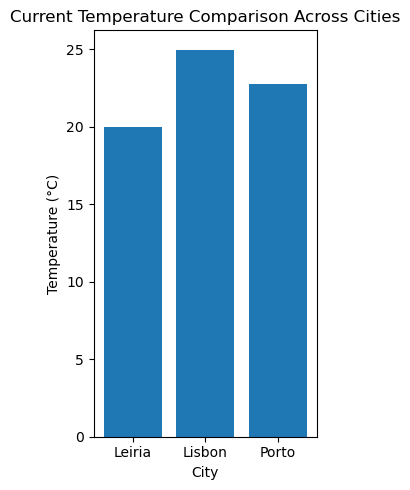

In [31]:
plt.figure(figsize=(3, 5))

plt.bar(
    df_analysis["City"],
    df_analysis["Temperature_C"]
)

plt.title("Current Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

### 4.F — Identify the City With the Highest and Lowest Humidity

In [32]:
highest_humidity = df_analysis.loc[
    df_analysis["Humidity_Percent"].idxmax(),
    ["City", "Humidity_Percent"]
]

print("City with the highest humidity:")
print(highest_humidity)

City with the highest humidity:
City                Leiria
Humidity_Percent        94
Name: 0, dtype: object


In [33]:
lowest_humidity = df_analysis.loc[
    df_analysis["Humidity_Percent"].idxmin(),
    ["City", "Humidity_Percent"]
]

print("City with the lowest humidity:")
print(lowest_humidity)

City with the lowest humidity:
City                Lisbon
Humidity_Percent        59
Name: 1, dtype: object


### 4.G — Humidity Visualization

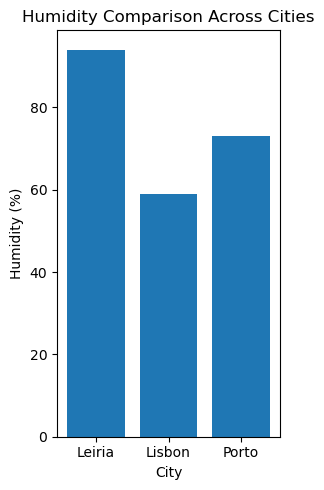

In [34]:
plt.figure(figsize=(3, 5))

plt.bar(
    df_analysis["City"],
    df_analysis["Humidity_Percent"]
)

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")

plt.tight_layout()
plt.show()

### 4.H — Compare Weather Conditions

In [35]:
weather_comparison = df_analysis[
    ["City", "Weather_Condition", "Weather_Description"]
]

weather_comparison

,City,Weather_Condition,Weather_Description
0,Leiria,Clouds,Few Clouds
1,Lisbon,Clouds,Overcast Clouds
2,Porto,Clouds,Broken Clouds


### 4.I — Analyze Wind Speed

In [36]:
highest_wind = df_analysis.loc[
    df_analysis["Wind_Speed_m_s"].idxmax(),
    ["City", "Wind_Speed_m_s"]
]

print("City with the highest wind speed:")
print(highest_wind)

City with the highest wind speed:
City              Lisbon
Wind_Speed_m_s      2.57
Name: 1, dtype: object


### 4.J — Wind Speed Vizualization

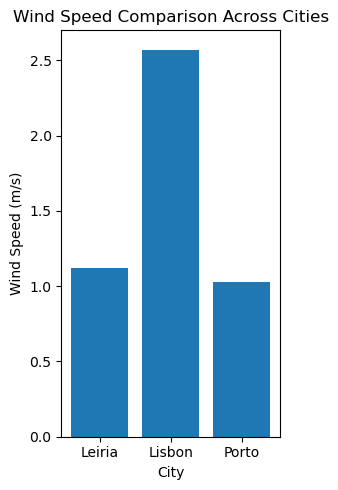

In [37]:
plt.figure(figsize=(3, 5))

plt.bar(
    df_analysis["City"],
    df_analysis["Wind_Speed_m_s"]
)

plt.title("Wind Speed Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Wind Speed (m/s)")

plt.tight_layout()
plt.show()

### 4.K — Short summary of findings

In [38]:
analysis_summary = df_analysis[
    [
        "City",
        "Temperature_C",
        "Humidity_Percent",
        "Wind_Speed_m_s",
        "Weather_Condition"
    ]
].copy()

analysis_summary

,City,Temperature_C,Humidity_Percent,Wind_Speed_m_s,Weather_Condition
0,Leiria,20.00,94,1.12,Clouds
1,Lisbon,24.96,59,2.57,Clouds
2,Porto,22.73,73,1.03,Clouds


In [39]:
warmest_city

City             Lisbon
Temperature_C     24.96
Name: 1, dtype: object

In [40]:
highest_humidity

City                Leiria
Humidity_Percent        94
Name: 0, dtype: object

In [41]:
highest_wind

City              Lisbon
Wind_Speed_m_s      2.57
Name: 1, dtype: object

## Task 5: Documentation

### Create a README file

readme_content = """
## Weather Data ETL Pipeline

### Project Overview

This project was developed as part of Week 7 of the AnalystLab Africa Data Analytics Internship. The objective was to build a basic ETL (Extract, Transform, Load) pipeline using real-time weather data obtained from the OpenWeather API.

The pipeline demonstrates how weather data can be extracted programmatically from an external API, cleaned and transformed using Python and Pandas, and loaded into structured CSV and Excel files for further analysis.

Weather data was collected for three cities in Portugal: **Leiria, Lisbon, and Porto**.

---

### Project Objective

The main objective of this project was to develop a simple and reusable ETL pipeline capable of:

* Extracting real-time weather information from an API.
* Transforming and cleaning the extracted data.
* Storing the processed dataset in usable formats.
* Performing basic analysis on the collected weather data.
* Producing insights from the processed dataset.

---

### Data Source

The weather data was collected from the **OpenWeather API**.

The API provides current weather information including temperature, humidity, weather conditions, wind speed, atmospheric pressure, and other meteorological information.

**Data Source:** OpenWeather API

The API was accessed using Python and the `Requests` library.

---

### ETL Process

The project follows three main stages:

#### 1. Extract

Weather data was extracted from the OpenWeather API using Python.

Weather information was collected for:

* Leiria
* Lisbon
* Porto

The following fields were retrieved:

* City
* Temperature
* Feels-like temperature
* Humidity
* Weather condition
* Weather description
* Wind speed
* Atmospheric pressure
* Date and time

The extracted data was stored as:

`raw_weather_data.csv`

---

#### 2. Transform

The raw weather data was transformed using Pandas.

The transformation process included:

* Loading the raw CSV dataset.
* Checking the dataset structure.
* Checking for missing values.
* Checking for duplicate records.
* Renaming columns where necessary.
* Converting numerical fields into appropriate numeric data types.
* Converting the Date/Time field into a datetime data type.
* Standardizing weather-condition text.
* Removing duplicate records.
* Organizing the columns into a logical structure.
* Creating a clean dataset ready for analysis.

The transformed dataset was saved as:

`Cleaned_weather_data.csv`

---

#### 3. Load

The cleaned dataset was loaded into an Excel file for future analysis and reporting.

The final Excel file was saved as:

`Weather_ETL_Data.xlsx`

The project therefore demonstrates the complete workflow:

**API → Python → Pandas → Clean Dataset → Excel**

---

### Tools and Technologies Used

The following tools and technologies were used:

* **Python** — Data extraction, transformation and analysis
* **Pandas** — Data manipulation and transformation
* **Requests** — API communication
* **Matplotlib** — Data visualization
* **Jupyter Notebook** — Development environment
* **OpenWeather API** — Real-time weather data source
* **Microsoft Excel** — Data storage and analysis
* **GitHub** — Project version control and portfolio publication

---

### Project Steps

The project was completed through the following stages:

#### Step 1 — API Setup

An OpenWeather account was created and an API key was generated.

#### Step 2 — Data Extraction

Python was used to connect to the OpenWeather API and retrieve weather information for three cities.

#### Step 3 — Raw Data Storage

The extracted API data was converted into a Pandas DataFrame and saved as a CSV file.

#### Step 4 — Data Transformation

The raw dataset was cleaned, structured, and converted into appropriate data types.

#### Step 5 — Data Loading

The cleaned dataset was saved as an Excel file for future analysis.

#### Step 6 — Data Analysis

The processed dataset was analyzed to compare temperature, humidity, wind speed, and weather conditions across the three cities.

#### Step 7 — Visualization

Charts were created to communicate the differences in temperature, humidity, and wind speed across the cities.

---

### Key Findings

The analysis produced the following findings from the weather observations collected:

#### Highest Temperature

**Lisbon** recorded the highest temperature among the three cities at **22.68°C** at the time of data collection.

#### Highest Humidity

**Porto** recorded the highest humidity at **88%**.

#### Highest Wind Speed

**Lisbon** recorded the highest wind speed at **13.38 m/s**.

#### Weather Conditions

Weather conditions and descriptions were compared across Leiria, Lisbon, and Porto using the information returned by the OpenWeather API.

---

### Visualizations

The project includes visualizations comparing:

1. Temperature across cities.
2. Humidity across cities.
3. Wind speed across cities.

The visualization files are stored in the `visualizations` directory.

---

### Project Structure

```text
Week7/
│
├── raw_weather_data.csv
├── Cleaned_weather_data.csv
├── Weather_ETL_Data.xlsx
├── README.md
│
├── notebooks/
│   └── Week7_Weather_ETL.ipynb
│
├── src/
│   └── weather_etl_pipeline.py
│
└── visualizations/
    ├── temperature_comparison.png
    ├── humidity_comparison.png
    └── wind_speed_comparison.png
```

---

### Limitations

This project uses current weather observations collected at a specific point in time.

Therefore, the results should not be interpreted as long-term climate patterns or historical weather trends.

The dataset contains one observation for each city, meaning that it is suitable for demonstrating the ETL process and basic comparison but not for advanced time-series analysis.

A larger project could collect weather data continuously over several days or weeks to enable trend analysis and more detailed comparisons.

---

### What I Learned

Through this project, I gained practical experience in:

* Working with REST APIs.
* Extracting real-time data using Python.
* Handling JSON API responses.
* Using Pandas for data transformation.
* Cleaning and structuring datasets.
* Converting data types.
* Saving data into CSV and Excel formats.
* Performing basic exploratory analysis.
* Creating data visualizations.
* Understanding the practical workflow of ETL pipelines.
* Preparing data for future analysis and reporting.

---

### Conclusion

This project successfully demonstrated the implementation of a basic ETL pipeline using real-time weather data.

The pipeline extracted data from the OpenWeather API, transformed and cleaned the data using Pandas, and loaded the processed dataset into an Excel file.

The analysis provided a simple comparison of weather conditions across Leiria, Lisbon, and Porto, with Lisbon recording the highest temperature and wind speed, while Porto recorded the highest humidity at the time of data collection.

Overall, the project provided practical experience in API integration, data transformation, data storage, analysis, visualization, and documentation, which are important skills for a data analyst working with real-world data pipelines.
"""

readme_path = r"C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\README.md"

with open(readme_path, "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md saved successfully!")


In [42]:
import os

api_key = os.getenv("OPENWEATHER_API_KEY")

if api_key:
    print("OpenWeather API key detected successfully!")
else:
    print("API key not detected.")

OpenWeather API key detected successfully!


In [43]:
%run "C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\ETL Pipeline Script\weather_etl_pipeline.py"

WEATHER DATA ETL PIPELINE

[1] EXTRACTING WEATHER DATA...
Successfully extracted weather data for Leiria
Successfully extracted weather data for Lisbon
Successfully extracted weather data for Porto

Raw data saved to: C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\raw_weather_data.csv

[2] TRANSFORMING DATA...
Transformed 3 records.

[3] LOADING DATA...

Data successfully loaded!
Cleaned CSV: C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\Cleaned_weather_data.csv
Excel file: C:\Users\egbet\OneDrive\Desktop\Internship2\Week7\Weather_ETL_Data.xlsx

ETL PIPELINE COMPLETED SUCCESSFULLY!
